# Airbnb Demand Prediction: Istanbul vs Paris

This project predicts Airbnb listing demand in Istanbul and Paris using listing, pricing, location, and host-related features. Demand is measured using `reviews_per_month`, which is used as a proxy for booking activity.

The main goal is to compare whether Airbnb demand drivers differ between Istanbul and Paris.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone


def analyze_city(file_path, city_name):
    print(f"===== {city_name} ANALYSIS STARTED =====")

    # Load dataset
    df = pd.read_csv(file_path)
    print(f"{city_name} dataset shape:", df.shape)

    # Target variable
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
    df["log_reviews_per_month"] = np.log1p(df["reviews_per_month"])

    # Clean price column
    if "price" in df.columns:
        df["price"] = (
            df["price"]
            .astype(str)
            .str.replace(r"[^0-9.]", "", regex=True)
        )
        df["price"] = pd.to_numeric(df["price"], errors="coerce")

    # Clean percentage columns
    for col in ["host_response_rate", "host_acceptance_rate"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace("%", "", regex=False)
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Selected features
    features = [
        "price",
        "room_type",
        "neighbourhood_cleansed",
        "accommodates",
        "bedrooms",
        "beds",
        "minimum_nights",
        "availability_365",
        "host_is_superhost",
        "host_response_rate",
        "host_acceptance_rate",
        "host_listings_count",
        "instant_bookable"
    ]

    # Keep only columns that exist in the dataset
    features = [col for col in features if col in df.columns]
    target = "log_reviews_per_month"

    data = df[features + [target]].copy()

    X = data[features]
    y = data[target]

    # Separate numeric and categorical features
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42
    )

    # Models
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=1.0),
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            min_samples_leaf=3,
            n_jobs=-1
        )
    }

    comparison_results = []
    trained_models = {}

    # Naive baseline
    baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

    comparison_results.append({
        "City": city_name,
        "Model": "Naive Baseline",
        "RMSE": np.sqrt(mean_squared_error(y_test, baseline_pred)),
        "MAE": mean_absolute_error(y_test, baseline_pred),
        "R2": r2_score(y_test, baseline_pred)
    })

    # Train models
    for name, regressor in models.items():
        pipeline = Pipeline(steps=[
            ("preprocessor", clone(preprocessor)),
            ("regressor", regressor)
        ])

        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        comparison_results.append({
            "City": city_name,
            "Model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
            "MAE": mean_absolute_error(y_test, predictions),
            "R2": r2_score(y_test, predictions)
        })

        trained_models[name] = pipeline

    comparison_df = pd.DataFrame(comparison_results)

    safe_city = city_name.lower().replace(" ", "_")

    # Save model comparison table
    comparison_df.to_csv(f"model_comparison_{safe_city}.csv", index=False)

    # RMSE graph
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df["Model"], comparison_df["RMSE"])
    plt.xlabel("Model")
    plt.ylabel("RMSE")
    plt.title(f"Model Comparison by RMSE - {city_name}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f"model_comparison_rmse_{safe_city}.png", dpi=300)
    plt.show()

    # R2 graph
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df["Model"], comparison_df["R2"])
    plt.xlabel("Model")
    plt.ylabel("R² Score")
    plt.title(f"Model Comparison by R² Score - {city_name}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f"model_comparison_r2_{safe_city}.png", dpi=300)
    plt.show()

    # Demand distribution before log transformation
    plt.figure(figsize=(8, 5))
    plt.hist(df["reviews_per_month"], bins=50)
    plt.xlabel("Reviews per Month")
    plt.ylabel("Frequency")
    plt.title(f"Demand Distribution Before Log Transformation - {city_name}")
    plt.tight_layout()
    plt.savefig(f"demand_distribution_before_log_{safe_city}.png", dpi=300)
    plt.show()

    # Demand distribution after log transformation
    plt.figure(figsize=(8, 5))
    plt.hist(df["log_reviews_per_month"], bins=50)
    plt.xlabel("Log(1 + Reviews per Month)")
    plt.ylabel("Frequency")
    plt.title(f"Demand Distribution After Log Transformation - {city_name}")
    plt.tight_layout()
    plt.savefig(f"demand_distribution_after_log_{safe_city}.png", dpi=300)
    plt.show()

    # Price vs demand graph
    if "price" in df.columns:
        price_plot_data = df[
            df["price"].notna() &
            np.isfinite(df["price"]) &
            df["log_reviews_per_month"].notna()
        ].copy()

        plt.figure(figsize=(8, 5))

        if len(price_plot_data) > 0:
            upper_limit = price_plot_data["price"].quantile(0.99)

            plt.scatter(
                price_plot_data["price"],
                price_plot_data["log_reviews_per_month"],
                alpha=0.2
            )

            if pd.notna(upper_limit) and np.isfinite(upper_limit) and upper_limit > 0:
                plt.xlim(0, upper_limit)
        else:
            plt.text(
                0.5,
                0.5,
                "Price data unavailable",
                ha="center",
                va="center"
            )

        plt.xlabel("Price")
        plt.ylabel("Log(1 + Reviews per Month)")
        plt.title(f"Price vs Airbnb Demand - {city_name}")
        plt.tight_layout()
        plt.savefig(f"price_vs_demand_{safe_city}.png", dpi=300)
        plt.show()

    # Room type vs demand
    if "room_type" in df.columns:
        df.boxplot(column="log_reviews_per_month", by="room_type", figsize=(8, 5))
        plt.xlabel("Room Type")
        plt.ylabel("Log(1 + Reviews per Month)")
        plt.title(f"Demand by Room Type - {city_name}")
        plt.suptitle("")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.savefig(f"demand_by_room_type_{safe_city}.png", dpi=300)
        plt.show()

    # Superhost vs demand
    if "host_is_superhost" in df.columns:
        df.boxplot(column="log_reviews_per_month", by="host_is_superhost", figsize=(7, 5))
        plt.xlabel("Is Superhost")
        plt.ylabel("Log(1 + Reviews per Month)")
        plt.title(f"Demand by Superhost Status - {city_name}")
        plt.suptitle("")
        plt.tight_layout()
        plt.savefig(f"demand_by_superhost_{safe_city}.png", dpi=300)
        plt.show()

    # Feature importance from Random Forest
    rf_pipeline = trained_models["Random Forest"]
    rf_model = rf_pipeline.named_steps["regressor"]
    fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]

    # Get feature names safely
    try:
        all_feature_names = fitted_preprocessor.get_feature_names_out()
    except:
        all_feature_names = [
            f"feature_{i}" for i in range(len(rf_model.feature_importances_))
        ]

    # Make sure feature names and importance values have same length
    min_len = min(len(all_feature_names), len(rf_model.feature_importances_))

    importance_df = pd.DataFrame({
        "City": [city_name] * min_len,
        "feature": all_feature_names[:min_len],
        "importance": rf_model.feature_importances_[:min_len]
    })

    importance_df = importance_df.sort_values(by="importance", ascending=False)
    importance_df.to_csv(f"feature_importance_{safe_city}.csv", index=False)

    top_20 = importance_df.head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(top_20["feature"][::-1], top_20["importance"][::-1])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top 20 Features Affecting Airbnb Demand - {city_name}")
    plt.tight_layout()
    plt.savefig(f"feature_importance_{safe_city}.png", dpi=300)
    plt.show()

    print(f"===== {city_name} ANALYSIS COMPLETED =====")

    return comparison_df, importance_df

===== Istanbul ANALYSIS STARTED =====
Istanbul dataset shape: (30051, 79)


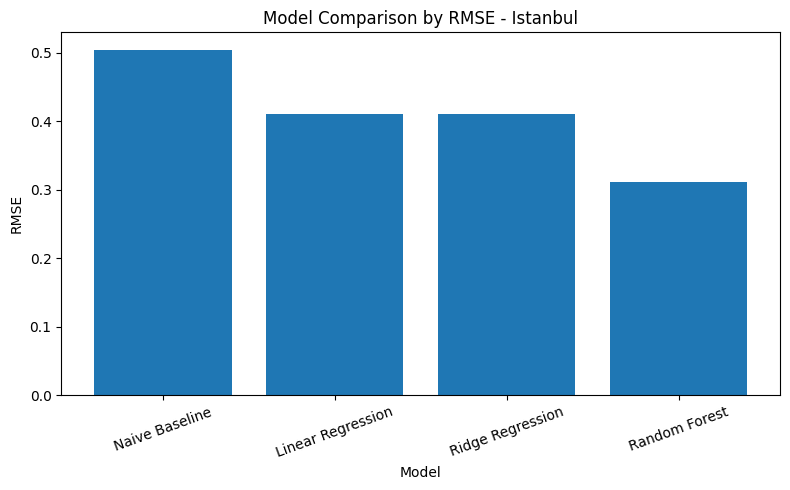

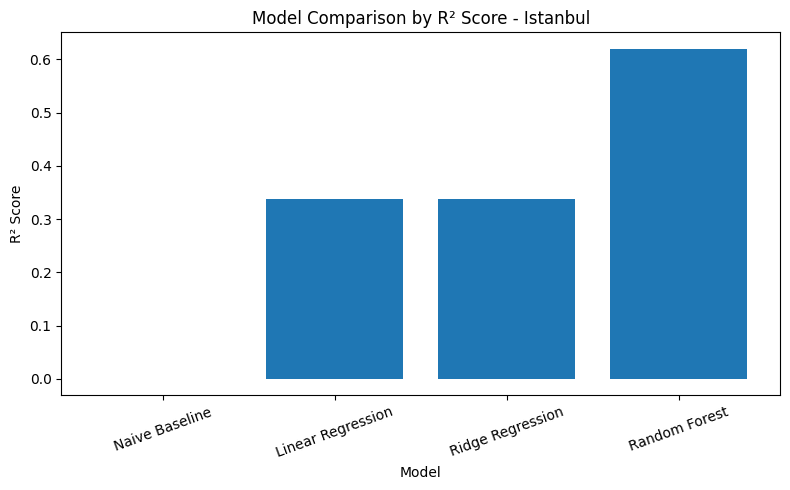

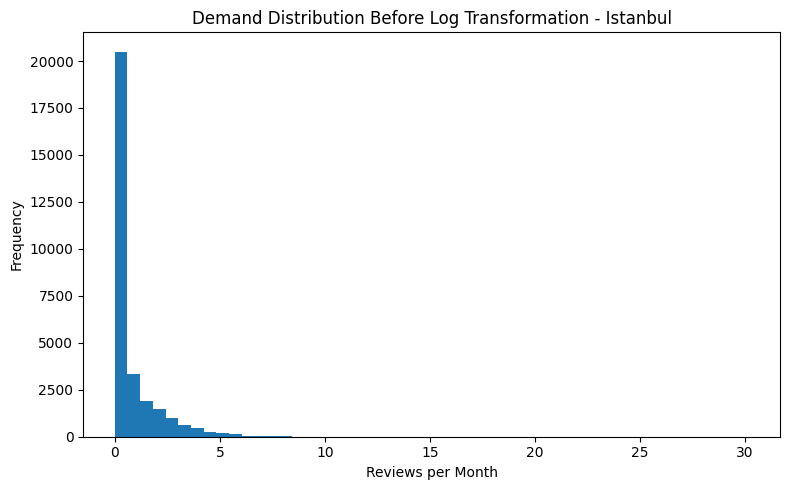

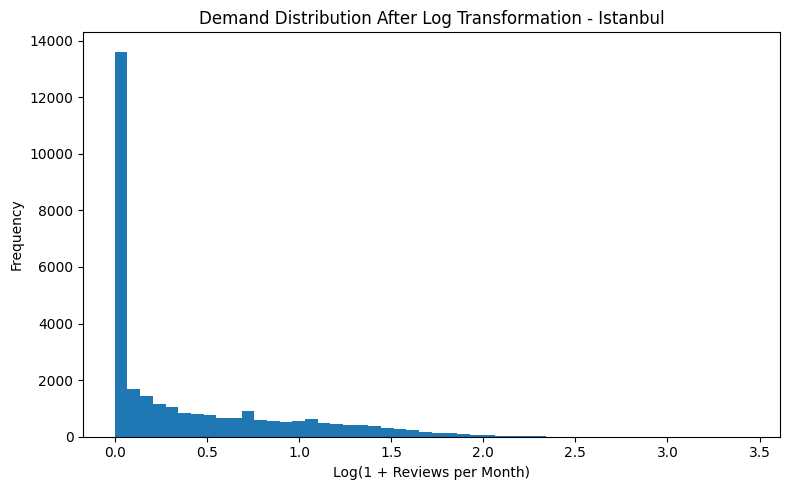

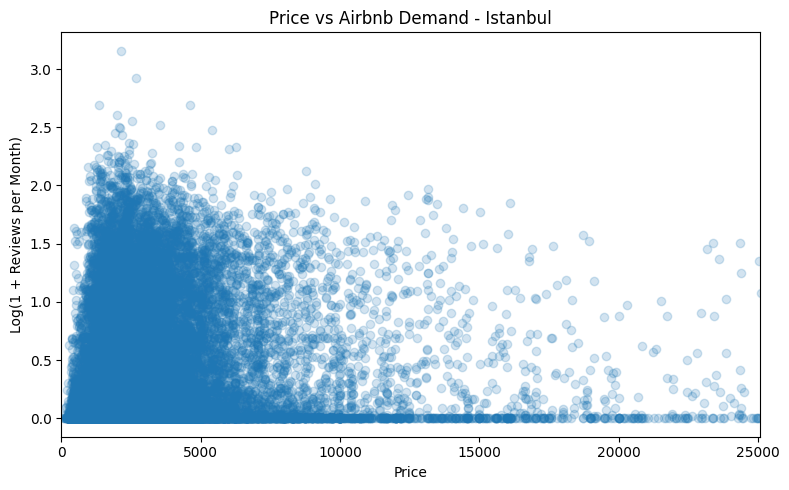

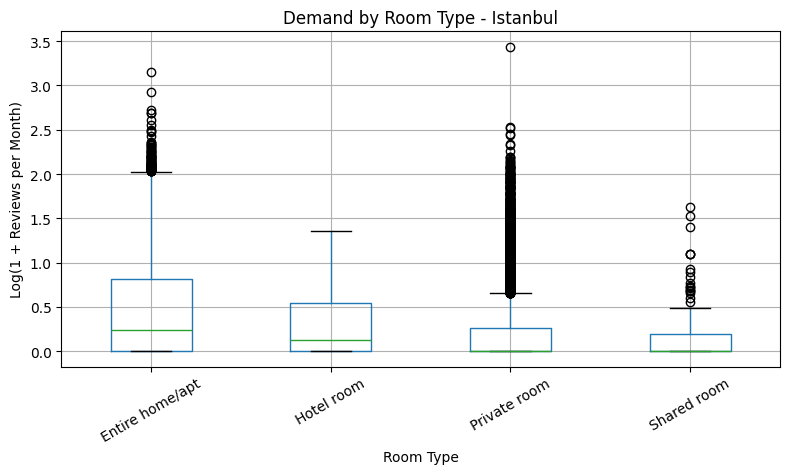

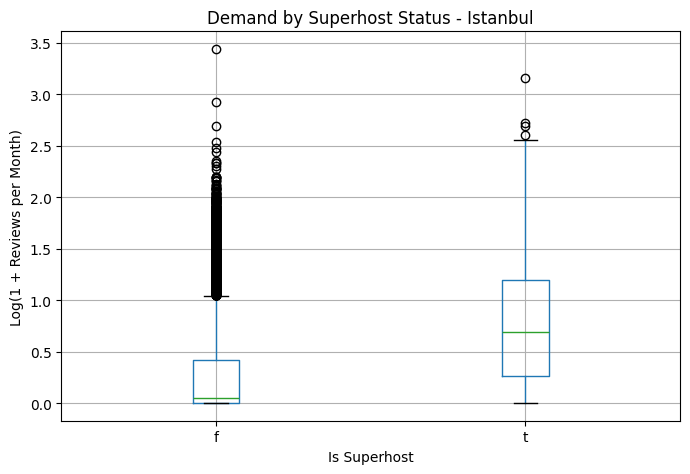

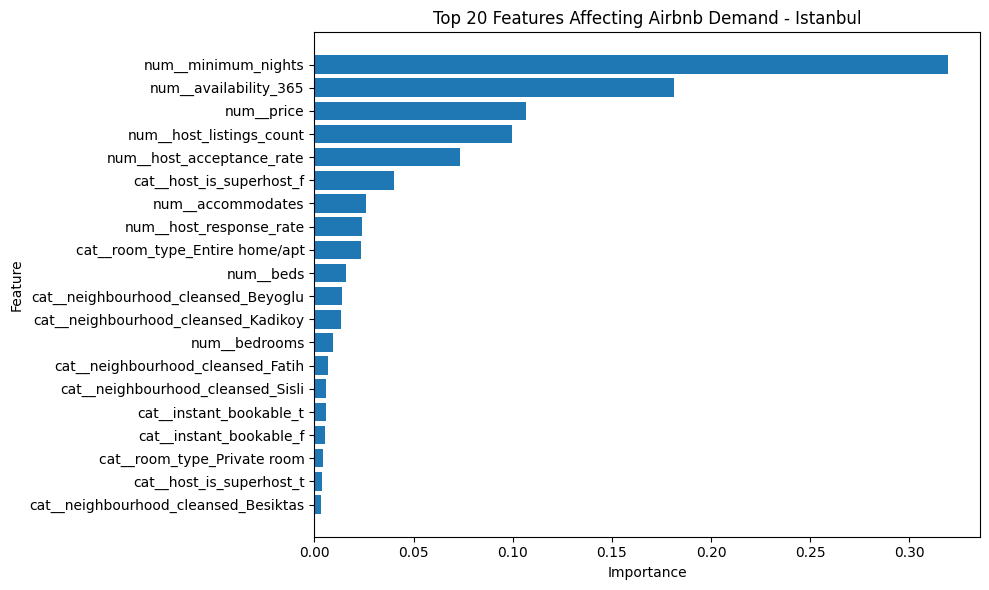

===== Istanbul ANALYSIS COMPLETED =====
===== Paris ANALYSIS STARTED =====
Paris dataset shape: (81853, 79)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['price' 'beds']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['price' 'beds']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['price' 'beds']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['price' 'beds']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.1

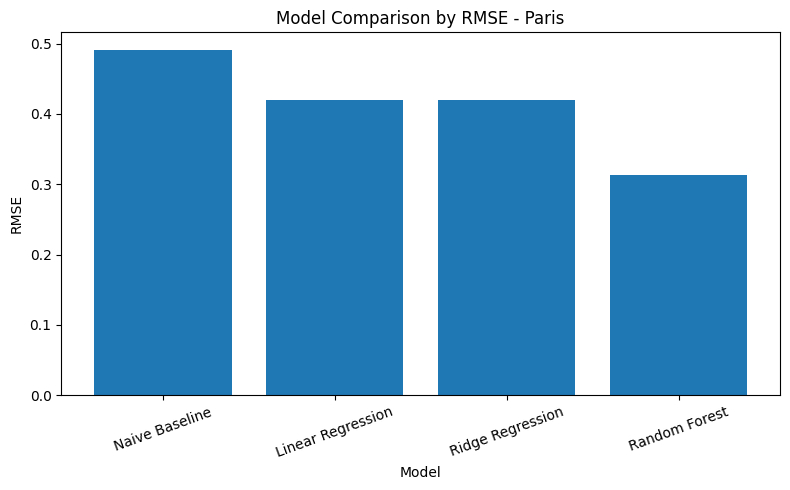

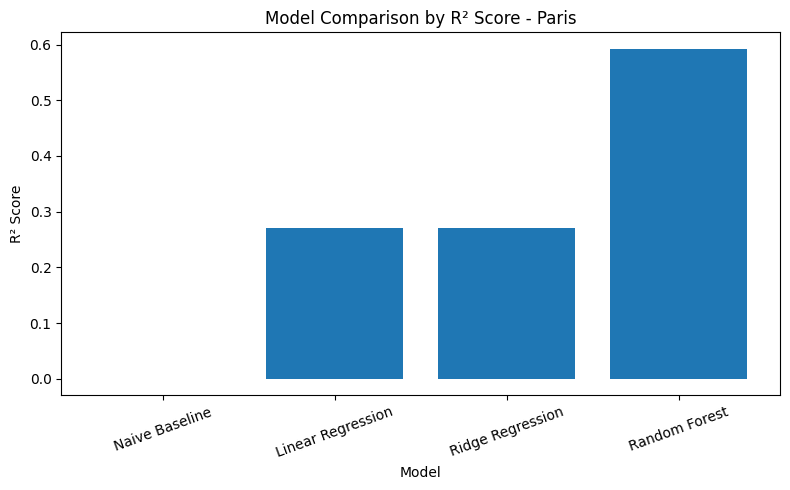

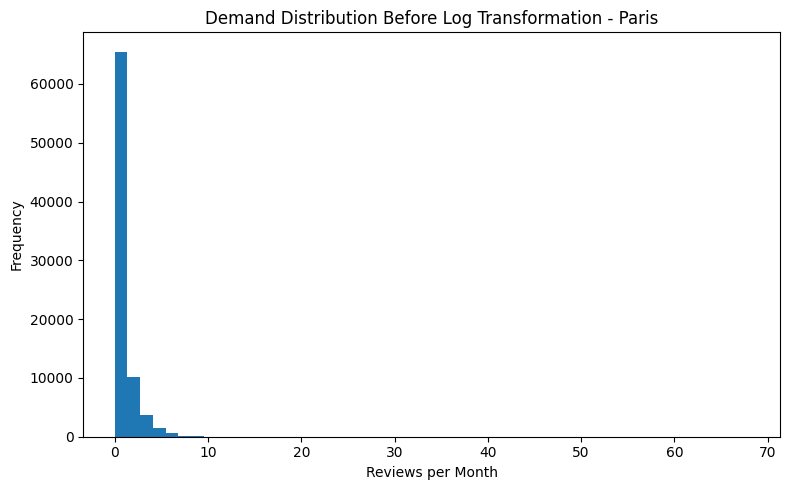

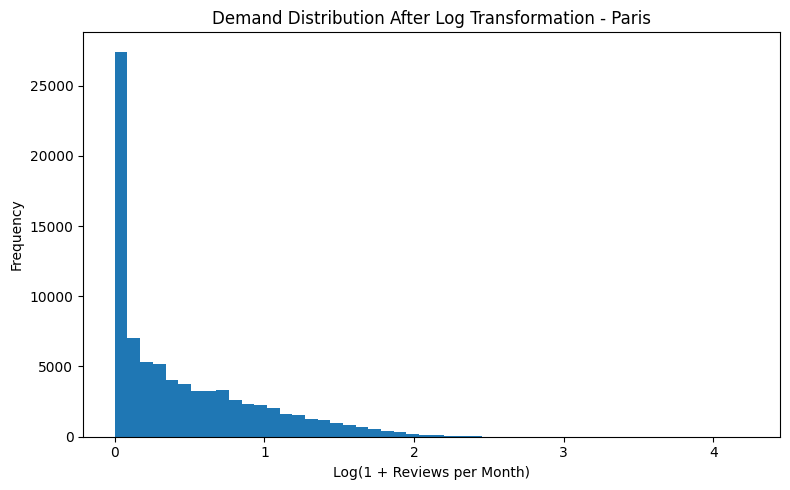

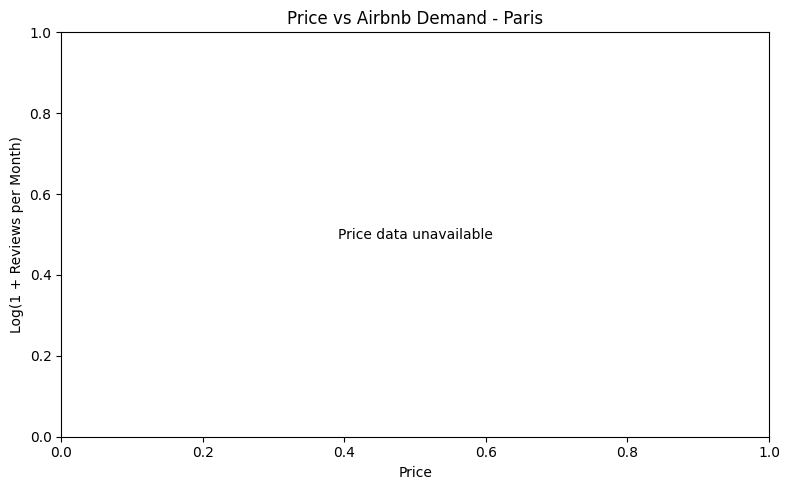

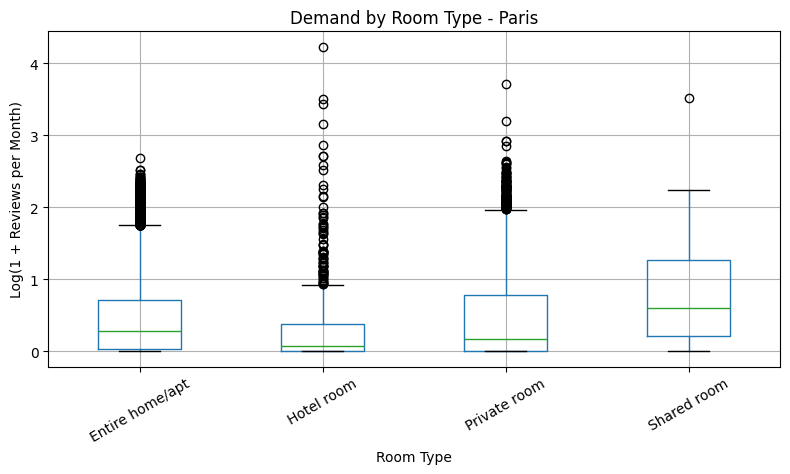

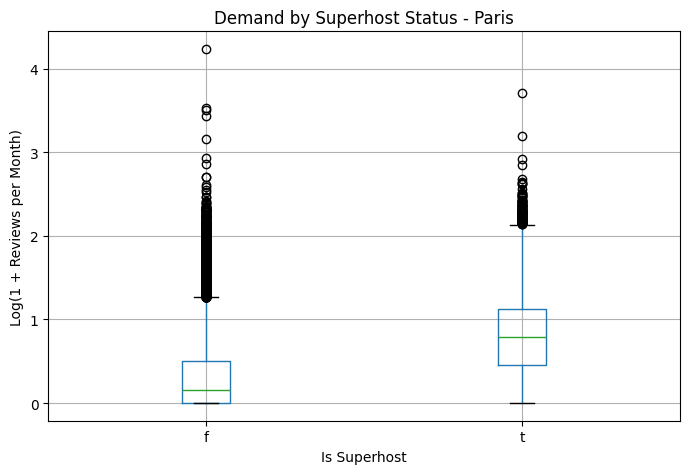

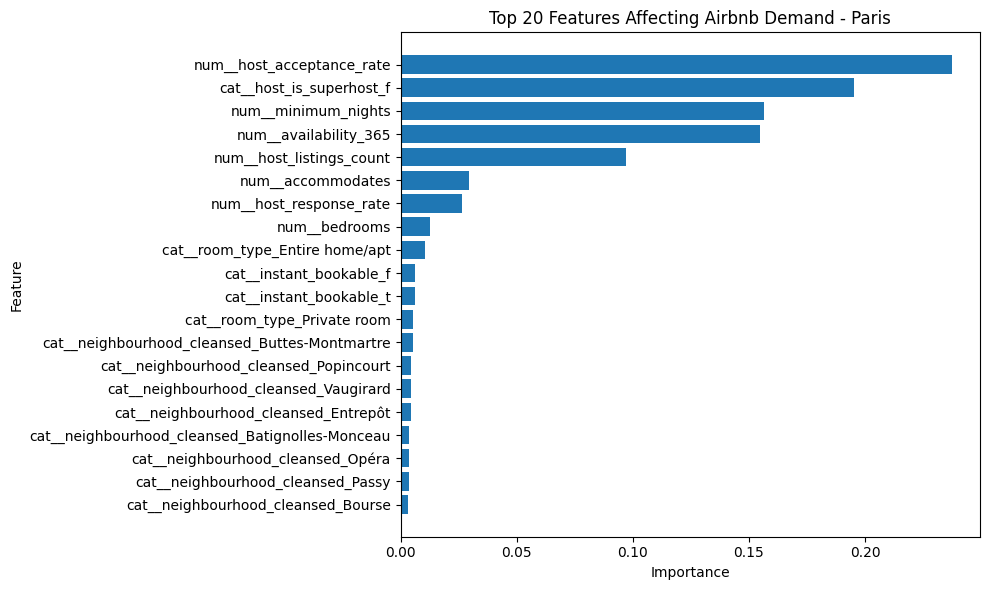

===== Paris ANALYSIS COMPLETED =====


In [ ]:
istanbul_results, istanbul_importance = analyze_city(
    "istanbul_listings.csv",
    "Istanbul"
)

paris_results, paris_importance = analyze_city(
    "paris_listings.csv",
    "Paris"
)

In [ ]:
all_results = pd.concat([istanbul_results, paris_results], ignore_index=True)
all_results.to_csv("model_comparison_istanstanbul_vs_paris.csv", index=False)
all_results

,City,Model,RMSE,MAE,R2
0,Istanbul,Naive Baseline,0.504684,0.413283,-0.000018
1,Istanbul,Linear Regression,0.410793,0.312999,0.337457
2,Istanbul,Ridge Regression,0.410781,0.312981,0.337495
3,Istanbul,Random Forest,0.311268,0.208673,0.619602
4,Paris,Naive Baseline,0.491321,0.400920,-0.000051
5,Paris,Linear Regression,0.419400,0.318725,0.271300
6,Paris,Ridge Regression,0.419400,0.318726,0.271302
7,Paris,Random Forest,0.313706,0.215284,0.592302


In [ ]:
rf_results = all_results[all_results["Model"] == "Random Forest"].copy()

rf_results.to_csv("random_forest_istanbul_vs_paris.csv", index=False)

rf_results

,City,Model,RMSE,MAE,R2
3,Istanbul,Random Forest,0.311268,0.208673,0.619602
7,Paris,Random Forest,0.313706,0.215284,0.592302


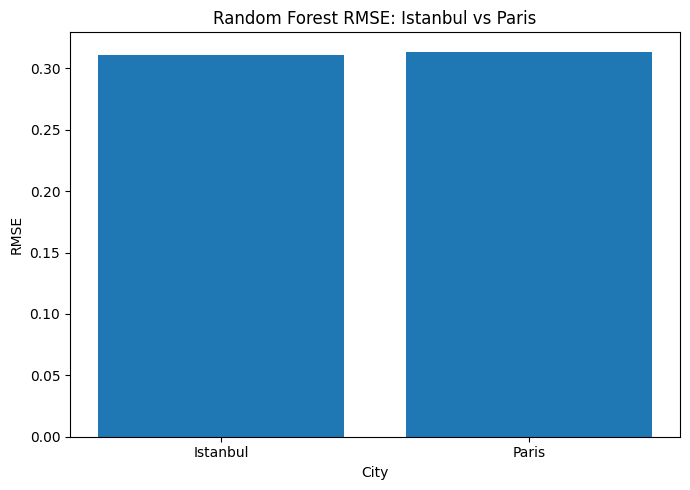

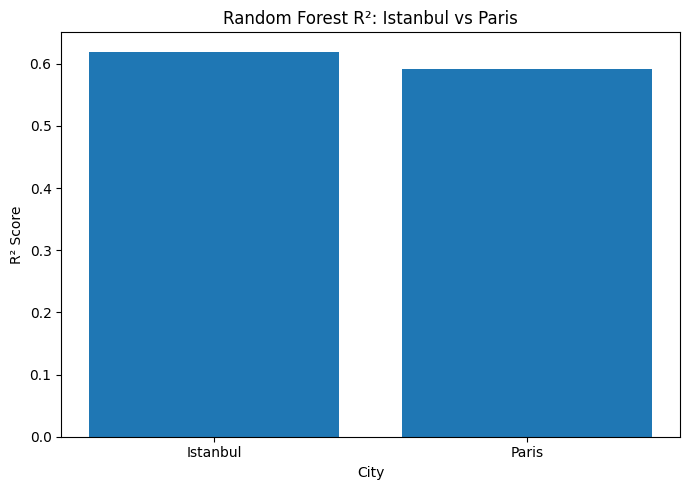

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(rf_results["City"], rf_results["RMSE"])
plt.xlabel("City")
plt.ylabel("RMSE")
plt.title("Random Forest RMSE: Istanbul vs Paris")
plt.tight_layout()
plt.savefig("random_forest_rmse_istanbul_vs_paris.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(rf_results["City"], rf_results["R2"])
plt.xlabel("City")
plt.ylabel("R² Score")
plt.title("Random Forest R²: Istanbul vs Paris")
plt.tight_layout()
plt.savefig("random_forest_r2_istanbul_vs_paris.png", dpi=300)
plt.show()

In [ ]:
top_istanbul = istanbul_importance.head(10)[["feature", "importance"]].reset_index(drop=True)
top_paris = paris_importance.head(10)[["feature", "importance"]].reset_index(drop=True)

feature_comparison = pd.DataFrame({
    "Istanbul Top Feature": top_istanbul["feature"],
    "Istanbul Importance": top_istanbul["importance"],
    "Paris Top Feature": top_paris["feature"],
    "Paris Importance": top_paris["importance"]
})

feature_comparison.to_csv("feature_comparison_istanbul_vs_paris.csv", index=False)

feature_comparison

,Istanbul Top Feature,Istanbul Importance,Paris Top Feature,Paris Importance
0,num__minimum_nights,0.319629,num__host_acceptance_rate,0.237677
1,num__availability_365,0.181292,cat__host_is_superhost_f,0.195291
2,num__price,0.106860,num__minimum_nights,0.156328
3,num__host_listings_count,0.099520,num__availability_365,0.154767
4,num__host_acceptance_rate,0.073328,num__host_listings_count,0.096911
5,cat__host_is_superhost_f,0.040011,num__accommodates,0.029494
6,num__accommodates,0.026110,num__host_response_rate,0.026604
7,num__host_response_rate,0.024216,num__bedrooms,0.012686
8,cat__room_type_Entire home/apt,0.023418,cat__room_type_Entire home/apt,0.010361
9,num__beds,0.015895,cat__instant_bookable_f,0.006382


In [ ]:
os.listdir("/content")

['.config',
 'model_comparison_paris.csv',
 'demand_by_room_type_istanbul.png',
 'model_comparison_r2_istanbul.png',
 'demand_distribution_before_log_istanbul.png',
 'demand_by_room_type_paris.png',
 'model_comparison_r2_paris.png',
 'random_forest_r2_istanbul_vs_paris.png',
 'price_vs_demand_paris.png',
 'demand_by_superhost_istanbul.png',
 'price_vs_demand_istanbul.png',
 'demand_distribution_after_log_istanbul.png',
 'feature_importance_istanbul.png',
 'feature_comparison_istanbul_vs_paris.csv',
 'demand_by_superhost_paris.png',
 'feature_importance_istanbul.csv',
 'model_comparison_istanbul.csv',
 'feature_importance_paris.csv',
 'model_comparison_rmse_paris.png',
 'random_forest_istanbul_vs_paris.csv',
 'demand_distribution_after_log_paris.png',
 'feature_importance_paris.png',
 '.ipynb_checkpoints',
 'model_comparison_rmse_istanbul.png',
 'random_forest_rmse_istanbul_vs_paris.png',
 'model_comparison_istanstanbul_vs_paris.csv',
 'demand_distribution_before_log_paris.png',
 'istan

In [ ]:
pd.read_csv("random_forest_istanbul_vs_paris.csv")

,City,Model,RMSE,MAE,R2
0,Istanbul,Random Forest,0.311268,0.208673,0.619602
1,Paris,Random Forest,0.313706,0.215284,0.592302


In [ ]:
pd.read_csv("feature_comparison_istanbul_vs_paris.csv")

,Istanbul Top Feature,Istanbul Importance,Paris Top Feature,Paris Importance
0,num__minimum_nights,0.319629,num__host_acceptance_rate,0.237677
1,num__availability_365,0.181292,cat__host_is_superhost_f,0.195291
2,num__price,0.106860,num__minimum_nights,0.156328
3,num__host_listings_count,0.099520,num__availability_365,0.154767
4,num__host_acceptance_rate,0.073328,num__host_listings_count,0.096911
5,cat__host_is_superhost_f,0.040011,num__accommodates,0.029494
6,num__accommodates,0.026110,num__host_response_rate,0.026604
7,num__host_response_rate,0.024216,num__bedrooms,0.012686
8,cat__room_type_Entire home/apt,0.023418,cat__room_type_Entire home/apt,0.010361
9,num__beds,0.015895,cat__instant_bookable_f,0.006382


In [ ]:
pd.read_csv("random_forest_istanbul_vs_paris.csv")

,City,Model,RMSE,MAE,R2
0,Istanbul,Random Forest,0.311268,0.208673,0.619602
1,Paris,Random Forest,0.313706,0.215284,0.592302
